In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("yfinance version:", yf.__version__)
print("pandas version:", pd.__version__)

d:\conda\envs\imageai\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
d:\conda\envs\imageai\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
d:\conda\envs\imageai\lib\site-packages\numpy\.libs\libopenblas.PYQHXLVVQ7VESDPUVUADXEVJOBGHJPAY.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


yfinance version: 1.2.0
pandas version: 2.0.3


In [17]:
TICKERS = {
    "gold": "GC=F",
    "dxy": "DX-Y.NYB",
    "vix": "^VIX",
    "sp500": "^GSPC"
}

TICKERS

{'gold': 'GC=F', 'dxy': 'DX-Y.NYB', 'vix': '^VIX', 'sp500': '^GSPC'}

In [18]:
gold_test = yf.download(
    "GC=F",
    period="5d",
    interval="1h",
    auto_adjust=False,
    progress=False
)

gold_test.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Datetime,,,,,,
2026-09-20 22:00:00+00:00,4412.100098,4412.100098,4417.799805,4412.000000,4415.000000,1331
2026-09-20 23:00:00+00:00,4411.600098,4411.600098,4414.799805,4406.899902,4412.200195,1537
2026-09-21 00:00:00+00:00,4404.799805,4404.799805,4414.299805,4396.399902,4411.500000,4771
2026-09-21 01:00:00+00:00,4415.700195,4415.700195,4422.100098,4404.799805,4404.799805,6000
2026-09-21 02:00:00+00:00,4401.500000,4401.500000,4416.200195,4399.000000,4416.000000,4445


In [19]:
print("Shape:", gold_test.shape)
print("Columns:")
print(gold_test.columns)

Shape: (85, 6)
Columns:
MultiIndex([('Adj Close', 'GC=F'),
            (    'Close', 'GC=F'),
            (     'High', 'GC=F'),
            (      'Low', 'GC=F'),
            (     'Open', 'GC=F'),
            (   'Volume', 'GC=F')],
           names=['Price', 'Ticker'])


In [20]:
def flatten_yfinance_columns(df):
    """
    Convert yfinance MultiIndex columns
    into normal single-level columns.
    """
    
    df = df.copy()
    
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    return df

In [21]:
gold_test = flatten_yfinance_columns(gold_test)

print(gold_test.columns)

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


In [22]:
print(gold_test.dtypes)

Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object


In [23]:
def download_market_data(
    ticker,
    period="30d",
    interval="1h"
):
    
    df = yf.download(
        ticker,
        period=period,
        interval=interval,
        auto_adjust=False,
        progress=False
    )
    
    # Fix MultiIndex
    df = flatten_yfinance_columns(df)
    
    # Sort timestamp
    df = df.sort_index()
    
    # Remove duplicate timestamps
    df = df[~df.index.duplicated(keep="last")]
    
    return df

In [24]:
data = {}

for name, ticker in TICKERS.items():
    
    print(f"Downloading {name} ({ticker})...")
    
    df = download_market_data(
        ticker=ticker,
        period="30d",
        interval="1h"
    )
    
    data[name] = df
    
    print(
        f"  rows = {len(df):,}, "
        f"start = {df.index.min()}, "
        f"end = {df.index.max()}"
    )

  rows = 557, start = 2026-08-20 04:00:00+00:00, end = 2026-09-24 12:00:00+00:00
  rows = 580, start = 2026-08-20 04:00:00+00:00, end = 2026-09-24 12:00:00+00:00
  rows = 407, start = 2026-08-14 07:00:00+00:00, end = 2026-09-24 12:00:00+00:00
  rows = 210, start = 2026-08-12 13:30:00+00:00, end = 2026-09-23 19:30:00+00:00


In [25]:
for name, df in data.items():
    
    print("=" * 60)
    print(name.upper())
    print("Shape:", df.shape)
    print("Start:", df.index.min())
    print("End:", df.index.max())
    print("Missing:")
    print(df.isna().sum())

GOLD
Shape: (557, 6)
Start: 2026-08-20 04:00:00+00:00
End: 2026-09-24 12:00:00+00:00
Missing:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
DXY
Shape: (580, 6)
Start: 2026-08-20 04:00:00+00:00
End: 2026-09-24 12:00:00+00:00
Missing:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
VIX
Shape: (407, 6)
Start: 2026-08-14 07:00:00+00:00
End: 2026-09-24 12:00:00+00:00
Missing:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64
SP500
Shape: (210, 6)
Start: 2026-08-12 13:30:00+00:00
End: 2026-09-23 19:30:00+00:00
Missing:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64


In [26]:
data["gold"].tail(10)

Price,Adj Close,Close,High,Low,Open,Volume
Datetime,,,,,,
2026-09-24 03:00:00+00:00,4318.899902,4318.899902,4328.700195,4315.600098,4325.399902,3021
2026-09-24 04:00:00+00:00,4324.299805,4324.299805,4325.100098,4316.399902,4320.100098,1482
2026-09-24 05:00:00+00:00,4313.600098,4313.600098,4331.200195,4312.000000,4324.399902,3081
2026-09-24 06:00:00+00:00,4311.299805,4311.299805,4321.299805,4309.000000,4313.799805,4797
2026-09-24 07:00:00+00:00,4313.299805,4313.299805,4323.000000,4309.000000,4311.200195,4374
2026-09-24 08:00:00+00:00,4295.500000,4295.500000,4320.299805,4295.000000,4313.399902,9339
2026-09-24 09:00:00+00:00,4289.700195,4289.700195,4301.700195,4285.000000,4295.500000,6193
2026-09-24 10:00:00+00:00,4292.500000,4292.500000,4299.399902,4278.299805,4289.600098,9544
2026-09-24 11:00:00+00:00,4300.399902,4300.399902,4302.399902,4286.399902,4292.399902,5179


In [27]:
data["gold"][["Open", "High", "Low", "Close", "Volume"]].tail()

Price,Open,High,Low,Close,Volume
Datetime,,,,,
2026-09-24 08:00:00+00:00,4313.399902,4320.299805,4295.000000,4295.500000,9339
2026-09-24 09:00:00+00:00,4295.500000,4301.700195,4285.000000,4289.700195,6193
2026-09-24 10:00:00+00:00,4289.600098,4299.399902,4278.299805,4292.500000,9544
2026-09-24 11:00:00+00:00,4292.399902,4302.399902,4286.399902,4300.399902,5179
2026-09-24 12:00:00+00:00,4300.200195,4305.399902,4295.000000,4302.600098,1418


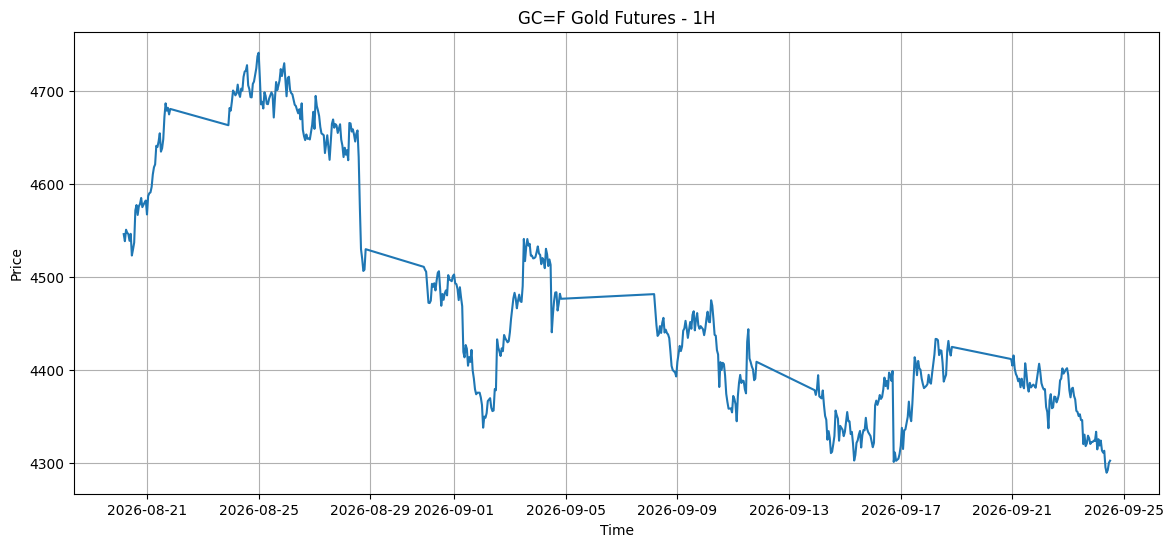

In [28]:
plt.figure(figsize=(14, 6))

plt.plot(
    data["gold"].index,
    data["gold"]["Close"]
)

plt.title("GC=F Gold Futures - 1H")
plt.xlabel("Time")
plt.ylabel("Price")

plt.grid(True)
plt.show()

In [29]:
gold = data["gold"].add_prefix("GOLD_")
dxy = data["dxy"].add_prefix("DXY_")
vix = data["vix"].add_prefix("VIX_")
sp500 = data["sp500"].add_prefix("SP500_")

In [30]:
market_df = pd.concat(
    [
        gold,
        dxy,
        vix,
        sp500
    ],
    axis=1
)

In [31]:
print(market_df.shape)
market_df.head()

(855, 24)


Price,GOLD_Adj Close,GOLD_Close,GOLD_High,GOLD_Low,GOLD_Open,GOLD_Volume,DXY_Adj Close,DXY_Close,DXY_High,DXY_Low,...,VIX_High,VIX_Low,VIX_Open,VIX_Volume,SP500_Adj Close,SP500_Close,SP500_High,SP500_Low,SP500_Open,SP500_Volume
Datetime,,,,,,,,,,,,,,,,,,,,,
2026-08-12 13:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7750.470215,7750.470215,7766.009766,7741.720215,7765.459961,0.0
2026-08-12 14:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7745.660156,7745.660156,7753.939941,7737.950195,7750.580078,288919983.0
2026-08-12 15:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7747.319824,7747.319824,7749.120117,7738.080078,7745.810059,227797073.0
2026-08-12 16:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7751.080078,7751.080078,7755.620117,7744.689941,7747.299805,206393000.0
2026-08-12 17:30:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,7753.419922,7753.419922,7755.399902,7749.589844,7751.209961,217011000.0


In [32]:
market_df.index = pd.to_datetime(market_df.index)

market_df = market_df.sort_index()

market_df = market_df[
    ~market_df.index.duplicated(keep="last")
]

In [33]:
print("Start:", market_df.index.min())
print("End:", market_df.index.max())
print("Duplicate:", market_df.index.duplicated().sum())

Start: 2026-08-12 13:30:00+00:00
End: 2026-09-24 12:00:00+00:00
Duplicate: 0


In [34]:
missing = market_df.isna().sum()

missing = missing[missing > 0]

missing

Price
GOLD_Adj Close     298
GOLD_Close         298
GOLD_High          298
GOLD_Low           298
GOLD_Open          298
GOLD_Volume        298
DXY_Adj Close      275
DXY_Close          275
DXY_High           275
DXY_Low            275
DXY_Open           275
DXY_Volume         275
VIX_Adj Close      448
VIX_Close          448
VIX_High           448
VIX_Low            448
VIX_Open           448
VIX_Volume         448
SP500_Adj Close    645
SP500_Close        645
SP500_High         645
SP500_Low          645
SP500_Open         645
SP500_Volume       645
dtype: int64

In [35]:
summary = pd.DataFrame({
    "Rows": [
        len(data["gold"]),
        len(data["dxy"]),
        len(data["vix"]),
        len(data["sp500"])
    ],
    "Start": [
        data["gold"].index.min(),
        data["dxy"].index.min(),
        data["vix"].index.min(),
        data["sp500"].index.min()
    ],
    "End": [
        data["gold"].index.max(),
        data["dxy"].index.max(),
        data["vix"].index.max(),
        data["sp500"].index.max()
    ]
}, index=[
    "GC=F",
    "DXY",
    "VIX",
    "SP500"
])

summary

,Rows,Start,End
GC=F,557,2026-08-20 04:00:00+00:00,2026-09-24 12:00:00+00:00
DXY,580,2026-08-20 04:00:00+00:00,2026-09-24 12:00:00+00:00
VIX,407,2026-08-14 07:00:00+00:00,2026-09-24 12:00:00+00:00
SP500,210,2026-08-12 13:30:00+00:00,2026-09-23 19:30:00+00:00


In [36]:
from pathlib import Path

DATA_DIR = Path("D:\AItrain\GoldMind\data")
DATA_DIR.mkdir(exist_ok=True)

In [37]:
for name, df in data.items():
    
    filename = DATA_DIR / f"{name}_1h_raw.csv"
    
    df.to_csv(filename)
    
    print("Saved:", filename)

Saved: D:\AItrain\GoldMind\data\gold_1h_raw.csv
Saved: D:\AItrain\GoldMind\data\dxy_1h_raw.csv
Saved: D:\AItrain\GoldMind\data\vix_1h_raw.csv
Saved: D:\AItrain\GoldMind\data\sp500_1h_raw.csv


In [38]:
combined_file = DATA_DIR / "market_data_1h_raw.csv"

market_df.to_csv(combined_file)

print("Saved:", combined_file)

Saved: D:\AItrain\GoldMind\data\market_data_1h_raw.csv


In [39]:
test_df = pd.read_csv(
    combined_file,
    index_col=0,
    parse_dates=True
)

print(test_df.shape)
print(test_df.head())
print(test_df.tail())

(855, 24)
                           GOLD_Adj Close  GOLD_Close  GOLD_High  GOLD_Low  \
Datetime                                                                     
2026-08-12 13:30:00+00:00             NaN         NaN        NaN       NaN   
2026-08-12 14:30:00+00:00             NaN         NaN        NaN       NaN   
2026-08-12 15:30:00+00:00             NaN         NaN        NaN       NaN   
2026-08-12 16:30:00+00:00             NaN         NaN        NaN       NaN   
2026-08-12 17:30:00+00:00             NaN         NaN        NaN       NaN   

                           GOLD_Open  GOLD_Volume  DXY_Adj Close  DXY_Close  \
Datetime                                                                      
2026-08-12 13:30:00+00:00        NaN          NaN            NaN        NaN   
2026-08-12 14:30:00+00:00        NaN          NaN            NaN        NaN   
2026-08-12 15:30:00+00:00        NaN          NaN            NaN        NaN   
2026-08-12 16:30:00+00:00        NaN          Na